> **Evaluation note.** This notebook now uses a **three-way train / val / test
> split**. The val split drives XGBoost hyperparameter selection and CNN epoch
> monitoring; all reported metrics come from the untouched test split.
>
> Previously there was no test split: the val set was used both to pick the best
> of 27 XGBoost configurations and to report the winning accuracy, so the
> headline numbers were the maximum over many draws rather than unbiased
> estimates.
>
> The confusion matrix is now generated for the **winning** model rather than
> always for XGBoost.
>
> **Outputs have been cleared** -- re-run in Colab to regenerate. The previously
> reported figures (EfficientNetB0 0.951 / XGBoost 0.949 macro-F1) were
> validation-set numbers and are not comparable to what this will produce.

# 07 — Disease Detection Model Development
### AgriVision AI — Disease Detection branch

Trains and compares 4 models (XGBoost, Random Forest, MobileNetV2, EfficientNetB0), picks the
best by macro-F1 on a held-out test split, and generates matched explainability (SHAP +
occlusion saliency for the tree branch, real Grad-CAM if a CNN wins).

It also emits a per-image severity CSV. Note that severity is a **constant looked up per
class**, not a quantity measured from the image — see Step 14.

## Step 1 — Install libraries

In [ ]:
!pip install xgboost shap scikit-image opencv-python-headless -q


## Step 2 — Kaggle authenticatio


In [ ]:
!pip install kaggle -q
from google.colab import files
files.upload()   # upload kaggle.json here
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Saving kaggle.json to kaggle.json


## Step 3 — Download PlantVillage dataset

In [ ]:
import os
!kaggle datasets download -d abdallahalidev/plantvillage-dataset
!unzip -q plantvillage-dataset.zip -d plantvillage_raw
print(os.listdir("plantvillage_raw"))


Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:15<00:00, 141MB/s]

['plantvillage dataset']


## Step 4 — Stratified train / val / test split

Restricted to Potato, Corn_(maize), Soybean — the crops overlapping the yield dataset.
Uses `plantvillage_raw/plantvillage dataset/color` — the actual nested path this dataset ships with.

**val** is for model selection (XGBoost hyperparameters, CNN epoch monitoring).
**test** is held out and only touched in Step 11.

In [ ]:
import os, random, shutil
import numpy as np

RNG = 42
random.seed(RNG); np.random.seed(RNG)

RAW_DIR = "plantvillage_raw/plantvillage dataset/color"
SPLIT_DIR = "data/images"
CROP_PREFIXES = ["Potato", "Corn_(maize)", "Soybean"]
# Cap per class. Raised from 300 to 1000: with a 15% test split, 300 left only
# ~45 test images per class (22 for Potato___healthy), too few for a stable
# per-class F1 -- and macro-F1 weights every class equally.
#
# This does NOT balance the classes. PlantVillage has only 152 Potato___healthy
# images in total, so that class stays at 152 while the others reach 1000, a
# ~6.6:1 imbalance. Balanced class weights (computed after the split) compensate.
MAX_PER_CLASS = 1000

# Three-way split: train / val / test.
#
# The original split was train/val only, and the val set was then used BOTH to
# choose XGBoost hyperparameters (27 configurations) AND to report the final
# accuracy. Selecting on the same data you report on biases the headline number
# upward -- the reported score is the maximum over 27 draws, not an unbiased
# estimate. Here val drives model selection and test stays untouched until the
# final evaluation.

def make_stratified_split(raw_dir=RAW_DIR, split_dir=SPLIT_DIR,
                           crop_prefixes=CROP_PREFIXES, max_per_class=MAX_PER_CLASS,
                           val_frac=0.15, test_frac=0.15):
    class_dirs = [d for d in sorted(os.listdir(raw_dir)) if any(d.startswith(p) for p in crop_prefixes)]
    if not class_dirs:
        raise RuntimeError(f"No class folders matched {crop_prefixes} under {raw_dir}")
    counts = {}
    for cls in class_dirs:
        src = os.path.join(raw_dir, cls)
        f_list = [f for f in os.listdir(src) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        random.shuffle(f_list)
        f_list = f_list[:max_per_class]
        n_test = max(1, int(len(f_list) * test_frac))
        n_val = max(1, int(len(f_list) * val_frac))
        test_f = f_list[:n_test]
        val_f = f_list[n_test:n_test + n_val]
        train_f = f_list[n_test + n_val:]
        for split_name, split_files in [("train", train_f), ("val", val_f), ("test", test_f)]:
            dst = os.path.join(split_dir, split_name, cls)
            os.makedirs(dst, exist_ok=True)
            for f in split_files:
                shutil.copy(os.path.join(src, f), os.path.join(dst, f))
        counts[cls] = {"train": len(train_f), "val": len(val_f), "test": len(test_f)}
    return counts

# clear any stale split before rebuilding, so re-runs never silently duplicate files
shutil.rmtree(SPLIT_DIR, ignore_errors=True)

counts = make_stratified_split(raw_dir=RAW_DIR)
for cls, c in counts.items():
    print(f"  {cls:<50} train={c['train']:4d}  val={c['val']:4d}  test={c['test']:4d}")
for split in ("train", "val", "test"):
    print(f"TOTAL {split}: {sum(c[split] for c in counts.values())}")

  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot train= 361  val=  76  test=  76
  Corn_(maize)___Common_rust_                        train= 700  val= 150  test= 150
  Corn_(maize)___Northern_Leaf_Blight                train= 691  val= 147  test= 147
  Corn_(maize)___healthy                             train= 700  val= 150  test= 150
  Potato___Early_blight                              train= 700  val= 150  test= 150
  Potato___Late_blight                               train= 700  val= 150  test= 150
  Potato___healthy                                   train= 108  val=  22  test=  22
  Soybean___healthy                                  train= 700  val= 150  test= 150
TOTAL train: 4660
TOTAL val: 995
TOTAL test: 995


## Step 5 — Classical-CV feature extraction

76 features per image: HSV color histogram (48) + LBP texture histogram (26) +
dark-pixel/brownish-pixel ratios (2). Used for the XGBoost/Random Forest branch.


In [ ]:
import cv2
import numpy as np
from skimage.feature import local_binary_pattern

IMG_SIZE = 128

def hsv_histogram(img_bgr, bins=16):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    hist = []
    for ch in range(3):
        h = cv2.calcHist([hsv], [ch], None, [bins], [0, 256])
        hist.append(cv2.normalize(h, h).flatten())
    return np.concatenate(hist)

def lbp_histogram(img_bgr, n_points=24, radius=3):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    lbp = local_binary_pattern(gray, n_points, radius, method="uniform")
    n_bins = n_points + 2
    hist, _ = np.histogram(lbp, bins=n_bins, range=(0, n_bins), density=True)
    return hist

def dark_and_brown_ratio(img_bgr):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    v = hsv[:, :, 2]
    dark_ratio = float(np.mean(v < 60))
    h, s = hsv[:, :, 0], hsv[:, :, 1]
    brown_mask = (h >= 5) & (h <= 25) & (s > 60) & (v > 20) & (v < 200)
    return np.array([dark_ratio, float(np.mean(brown_mask))])

def extract_features(img_bgr):
    img_bgr = cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE))
    return np.concatenate([
        hsv_histogram(img_bgr), lbp_histogram(img_bgr), dark_and_brown_ratio(img_bgr)
    ]).astype(np.float32)

FEATURE_NAMES = (
    [f"hsv_h_{i}" for i in range(16)] + [f"hsv_s_{i}" for i in range(16)] +
    [f"hsv_v_{i}" for i in range(16)] + [f"lbp_{i}" for i in range(26)] +
    ["dark_pixel_ratio", "brownish_pixel_ratio"]
)

def build_dataset(split_dir=SPLIT_DIR, split="train"):
    root = os.path.join(split_dir, split)
    classes = sorted(os.listdir(root))
    X, y, paths = [], [], []
    for ci, cls in enumerate(classes):
        cls_dir = os.path.join(root, cls)
        for f in sorted(os.listdir(cls_dir)):
            fp = os.path.join(cls_dir, f)
            img = cv2.imread(fp)
            if img is None:
                continue
            X.append(extract_features(img)); y.append(ci); paths.append(fp)
    X = np.array(X, dtype=np.float32); y = np.array(y, dtype=np.int64)
    print(f"[{split}] {len(X)} images | {X.shape[1]} features | {len(classes)} classes")
    return X, y, classes, paths

Xtr, ytr, classes, _ = build_dataset(split="train")
Xva, yva, classes_va, val_paths = build_dataset(split="val")
Xte, yte, classes_te, test_paths = build_dataset(split="test")
assert classes == classes_va == classes_te, "class order mismatch across splits"
n_classes = len(classes)
print("Classes:", classes)


# ---------------------------------------------------------------------------
# Balanced class weights.
#
# The per-class cap does not equalise the classes: PlantVillage only has 152
# Potato___healthy images, so it stays at 152 while others reach 1000. Without
# weighting, a model can score well on accuracy by quietly neglecting the rare
# class -- and Potato___healthy already had the weakest precision in the earlier
# run. These weights are applied to all four models below.
# ---------------------------------------------------------------------------
from sklearn.utils.class_weight import compute_class_weight

_weights = compute_class_weight("balanced", classes=np.arange(n_classes), y=ytr)
CLASS_WEIGHT = {i: float(w) for i, w in enumerate(_weights)}
SAMPLE_WEIGHT_TR = np.array([CLASS_WEIGHT[int(y)] for y in ytr], dtype=np.float32)

print("\nClass weights (train split):")
for i, cls in enumerate(classes):
    print(f"  {cls:<55} n={int((ytr == i).sum()):5d}  w={CLASS_WEIGHT[i]:.2f}")

[train] 4660 images | 76 features | 8 classes
[val] 995 images | 76 features | 8 classes
[test] 995 images | 76 features | 8 classes
Classes: ['Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Soybean___healthy']

Class weights (train split):
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      n=  361  w=1.61
  Corn_(maize)___Common_rust_                             n=  700  w=0.83
  Corn_(maize)___Northern_Leaf_Blight                     n=  691  w=0.84
  Corn_(maize)___healthy                                  n=  700  w=0.83
  Potato___Early_blight                                   n=  700  w=0.83
  Potato___Late_blight                                    n=  700  w=0.83
  Potato___healthy                                        n=  108  w=5.39
  Soybean___healthy                                       n=  700  w=

## Step 6 — Output folders (local to this session)

In [ ]:
OUT_FIG = "outputs/figures"
OUT_MET = "outputs/metrics"
ART = "artifacts_disease"
for d in [OUT_FIG, OUT_MET, ART]:
    os.makedirs(d, exist_ok=True)
print("Output folders ready:", OUT_FIG, OUT_MET, ART)


Output folders ready: outputs/figures outputs/metrics artifacts_disease


## Step 7 — Build CNN-ready image datasets (for MobileNetV2 / EfficientNetB0)

`TEST_FILE_PATHS` is captured **before** `.prefetch()` wraps the dataset — `.prefetch()` strips
the `.file_paths` attribute, so grabbing it here avoids a later crash.

In [ ]:
import tensorflow as tf
print("GPU available:", tf.config.list_physical_devices('GPU'))
# If this prints [], go to Runtime -> Change runtime type -> T4 GPU, then Runtime -> Restart session.

IMG_SIZE_CNN = 224
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(f"{SPLIT_DIR}/train",
    image_size=(IMG_SIZE_CNN, IMG_SIZE_CNN), batch_size=BATCH_SIZE, label_mode="int", shuffle=True, seed=RNG)
val_ds = tf.keras.utils.image_dataset_from_directory(f"{SPLIT_DIR}/val",
    image_size=(IMG_SIZE_CNN, IMG_SIZE_CNN), batch_size=BATCH_SIZE, label_mode="int", shuffle=False)
test_ds = tf.keras.utils.image_dataset_from_directory(f"{SPLIT_DIR}/test",
    image_size=(IMG_SIZE_CNN, IMG_SIZE_CNN), batch_size=BATCH_SIZE, label_mode="int", shuffle=False)

assert train_ds.class_names == classes, "class order mismatch between classical and CNN pipelines"
TEST_FILE_PATHS = test_ds.file_paths   # capture now, before prefetch wraps the dataset

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)
print("CNN datasets ready. Classes:", classes)

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found 4660 files belonging to 8 classes.
Found 995 files belonging to 8 classes.
Found 995 files belonging to 8 classes.
CNN datasets ready. Classes: ['Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Soybean___healthy']


## Step 8 — Train XGBoost (tuned by macro-F1) + Random Forest baseline

In [ ]:
from sklearn.model_selection import ParameterGrid
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import xgboost as xgb

def train_xgb(Xtr, ytr, Xva, yva, n_classes, sample_weight=None):
    grid = ParameterGrid({"max_depth": [3, 4, 6], "learning_rate": [0.05, 0.1, 0.2], "n_estimators": [150, 200, 300]})
    best_f1, best_model, best_params = -1, None, None
    for params in grid:
        model = xgb.XGBClassifier(objective="multi:softprob", num_class=n_classes,
                                   eval_metric="mlogloss", random_state=RNG, n_jobs=-1, **params)
        # XGBClassifier has no class_weight; per-sample weights are the equivalent.
        model.fit(Xtr, ytr, sample_weight=sample_weight)
        f1 = f1_score(yva, model.predict(Xva), average="macro")
        if f1 > best_f1:
            best_f1, best_model, best_params = f1, model, params
    print(f"Best XGB params: {best_params} | val macro-F1={best_f1:.3f}")
    return best_model

xgb_model = train_xgb(Xtr, ytr, Xva, yva, n_classes, sample_weight=SAMPLE_WEIGHT_TR)

rf = RandomForestClassifier(n_estimators=300, random_state=RNG, n_jobs=-1,
                             class_weight="balanced")
rf.fit(Xtr, ytr)
print("Tree models trained (class-weighted).")

Best XGB params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300} | val macro-F1=0.961
Tree models trained (class-weighted).


## Step 9 — Train MobileNetV2 (transfer learning, frozen base)

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mnv2_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess

def build_transfer_model(base_class, preprocess_fn, n_classes, img_size=IMG_SIZE_CNN):
    base = base_class(include_top=False, weights="imagenet", input_shape=(img_size, img_size, 3))
    base.trainable = False
    inputs = layers.Input(shape=(img_size, img_size, 3))
    x = preprocess_fn(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model, base

mobilenet_model, mobilenet_base = build_transfer_model(MobileNetV2, mnv2_preprocess, n_classes)
history_mnv2 = mobilenet_model.fit(train_ds, validation_data=val_ds, epochs=8,
                                    class_weight=CLASS_WEIGHT)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 53s 233ms/step - accuracy: 0.8064 - loss: 0.5919 - val_accuracy: 0.9447 - val_loss: 0.1687
Epoch 2/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9322 - loss: 0.2241 - val_accuracy: 0.9518 - val_loss: 0.1298
Epoch 3/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.9418 - loss: 0.1791 - val_accuracy: 0.9719 - val_loss: 0.1029
Epoch 4/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.9530 - loss: 0.1440 - val_accuracy: 0.9648 - val_loss: 0.0970
Epoch 5/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.9592 - loss: 0.1248 - val_accuracy: 0.9618 - val_loss: 0.1037
Epoch 6/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.9635 - loss: 0.1112 - val_accuracy: 0.9678 - val_loss: 0.0897
Epoch 7/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - accuracy: 0.9622 - loss: 0.1093 - val_accuracy: 0.9658 - val_loss: 0.0860
Epoch 8/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step 

## Step 10 — Train EfficientNetB0 (transfer learning, frozen base)

In [ ]:
efficientnet_model, efficientnet_base = build_transfer_model(EfficientNetB0, effnet_preprocess, n_classes)
history_effnet = efficientnet_model.fit(train_ds, validation_data=val_ds, epochs=8,
                                         class_weight=CLASS_WEIGHT)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 63s 259ms/step - accuracy: 0.8187 - loss: 0.6524 - val_accuracy: 0.9568 - val_loss: 0.2202
Epoch 2/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.9397 - loss: 0.2448 - val_accuracy: 0.9678 - val_loss: 0.1397
Epoch 3/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.9575 - loss: 0.1766 - val_accuracy: 0.9709 - val_loss: 0.1074
Epoch 4/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.9594 - loss: 0.1453 - val_accuracy: 0.9739 - val_loss: 0.0910
Epoch 5/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.9633 - loss: 0.1351 - val_accuracy: 0.9759 - val_loss: 0.0836
Epoch 6/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9689 - loss: 0.1189 - val_accuracy: 0.9789 - val_loss: 0.0762
Epoch 7/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.9695 - loss: 0.1089 - val_accuracy: 0.9759 - val_loss: 0.0723
Epoch 8/8
146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/ste

## Step 11 — Evaluate all 4 models on the held-out test split, pick the winner by macro-F1

Metrics come from **test**, which nothing above has seen. The val split was consumed by
hyperparameter search and epoch monitoring, so a score reported on it would be the value that
selection maximised rather than an unbiased estimate.

The confusion matrix is generated for the winning model.


XGBoost: accuracy=0.970  macro-F1=0.955
                                                    precision    recall  f1-score   support

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.89      0.86      0.87        76
                       Corn_(maize)___Common_rust_       0.99      1.00      1.00       150
               Corn_(maize)___Northern_Leaf_Blight       0.92      0.95      0.93       147
                            Corn_(maize)___healthy       1.00      1.00      1.00       150
                             Potato___Early_blight       0.99      0.99      0.99       150
                              Potato___Late_blight       0.97      0.97      0.97       150
                                  Potato___healthy       0.87      0.91      0.89        22
                                 Soybean___healthy       1.00      0.99      0.99       150

                                          accuracy                           0.97       995
                                     

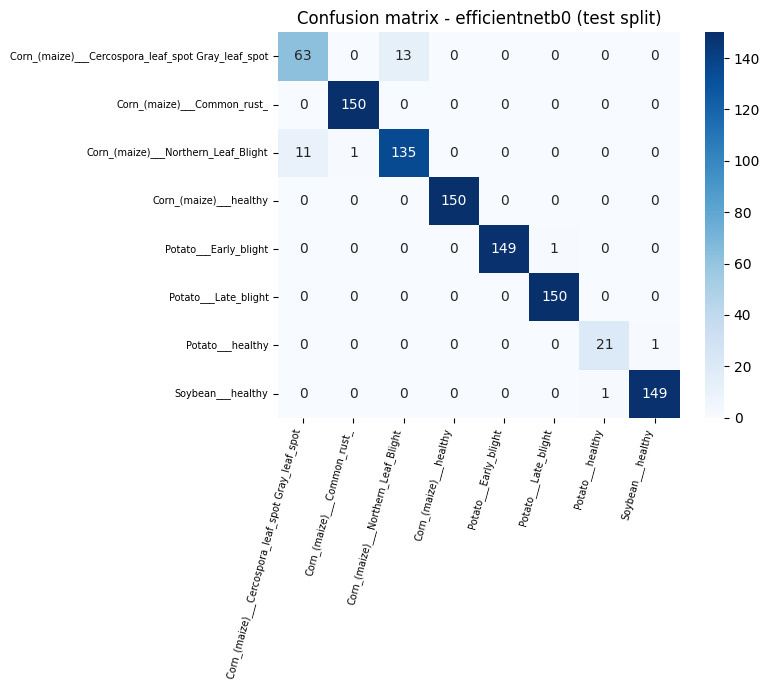

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Final evaluation on the held-out TEST split. The val split was used for
# hyperparameter selection and epoch monitoring, so reporting on it would be
# reporting the score that selection maximised.
metrics = {}

def evaluate(model, X, y, classes, name):
    preds = model.predict(X)
    acc = accuracy_score(y, preds); f1 = f1_score(y, preds, average="macro")
    print(f"\n{name}: accuracy={acc:.3f}  macro-F1={f1:.3f}")
    print(classification_report(y, preds, target_names=classes, zero_division=0))
    return {"accuracy": float(acc), "macro_f1": float(f1)}, np.asarray(preds)

metrics["xgboost"], xgb_preds = evaluate(xgb_model, Xte, yte, classes, "XGBoost")
metrics["random_forest"], rf_preds = evaluate(rf, Xte, yte, classes, "RandomForest")

def evaluate_keras_model(model, ds, name):
    y_true, y_pred = [], []
    for xb, yb in ds:
        preds = model.predict(xb, verbose=0)
        y_true.extend(yb.numpy().tolist()); y_pred.extend(np.argmax(preds, axis=1).tolist())
    acc = accuracy_score(y_true, y_pred); f1 = f1_score(y_true, y_pred, average="macro")
    print(f"{name}: accuracy={acc:.3f} macro-F1={f1:.3f}")
    return {"accuracy": float(acc), "macro_f1": float(f1)}, np.array(y_true), np.array(y_pred)

metrics["mobilenetv2"], mnv2_true, mnv2_preds = evaluate_keras_model(mobilenet_model, test_ds, "MobileNetV2")
metrics["efficientnetb0"], effnet_true, effnet_preds = evaluate_keras_model(efficientnet_model, test_ds, "EfficientNetB0")

print("\n=== Model comparison on the held-out test split (macro-F1 decides the winner) ===")
for k, v in sorted(metrics.items(), key=lambda kv: -kv[1]["macro_f1"]):
    print(f"{k:<18} acc={v['accuracy']:.3f}  macro-F1={v['macro_f1']:.3f}")
best_model_name = max(metrics, key=lambda k: metrics[k]["macro_f1"])
print(f"\nBEST MODEL: {best_model_name}")

# Confusion matrix for the WINNING model. The original always plotted XGBoost's,
# while the app shipped EfficientNetB0 and captioned the figure as if it
# described the served model.
truth_by_name = {
    "xgboost": yte, "random_forest": yte,
    "mobilenetv2": mnv2_true, "efficientnetb0": effnet_true,
}
preds_by_name = {
    "xgboost": xgb_preds, "random_forest": rf_preds,
    "mobilenetv2": mnv2_preds, "efficientnetb0": effnet_preds,
}

cm = confusion_matrix(truth_by_name[best_model_name], preds_by_name[best_model_name])
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_title(f"Confusion matrix - {best_model_name} (test split)")
plt.xticks(rotation=75, ha="right", fontsize=7); plt.yticks(fontsize=7)
plt.tight_layout(); plt.savefig(f"{OUT_FIG}/disease_confusion_matrix.png", dpi=150); plt.show()

## Step 12 — Explainability: SHAP + occlusion saliency (tree branch)

Generated regardless of which model wins, since it documents the classical-CV branch's behavior.


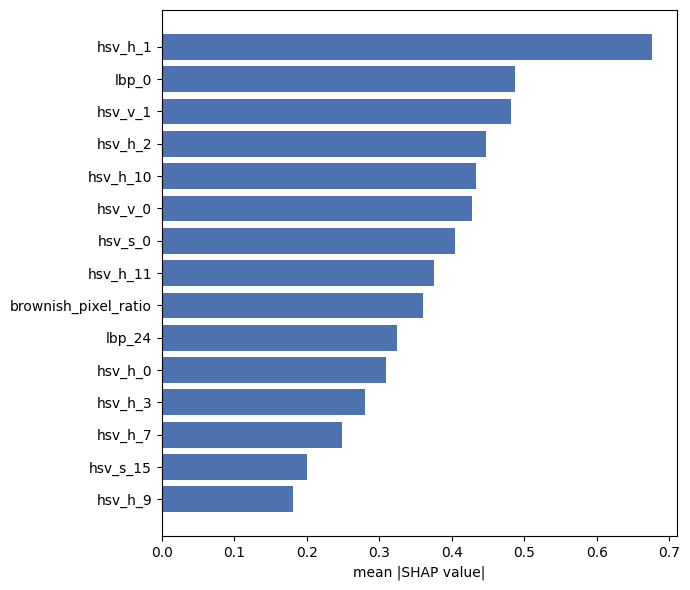

Top 5 features: [('hsv_h_1', 0.6762343049049377), ('lbp_0', 0.487504243850708), ('hsv_v_1', 0.48206377029418945), ('hsv_h_2', 0.446595162153244), ('hsv_h_10', 0.4333140552043915)]


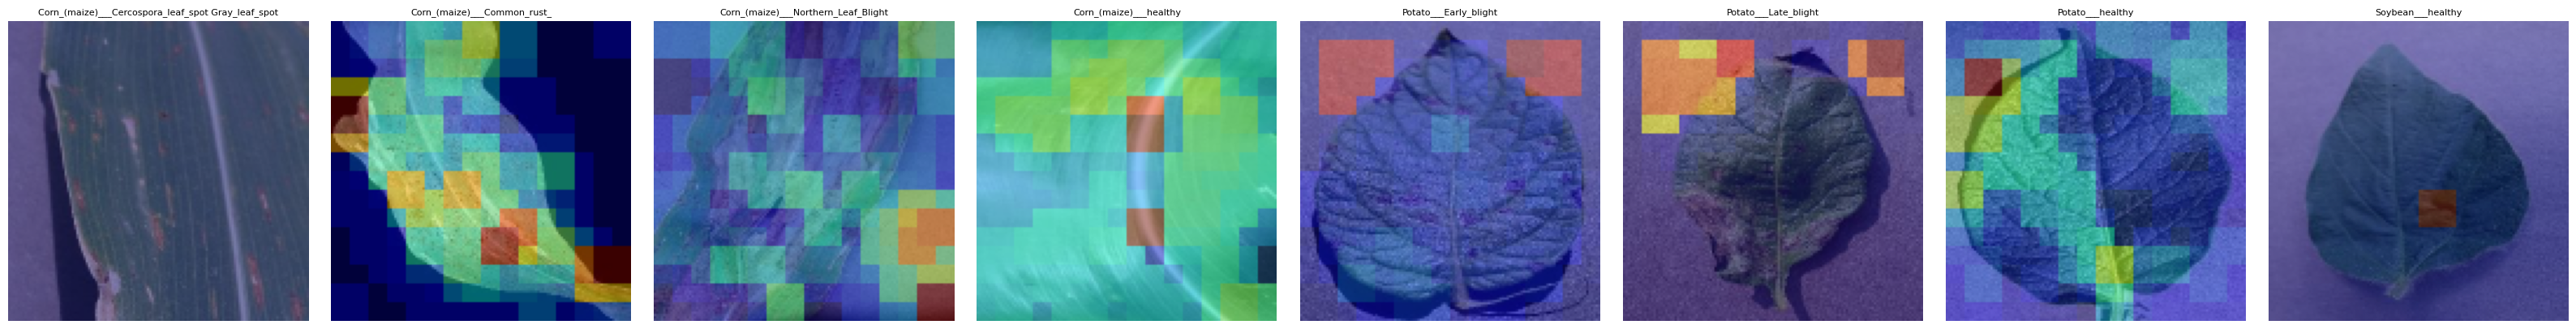

In [ ]:
import shap

def shap_global_importance(model, X, path, top_n=15):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    if isinstance(shap_values, list):
        mean_abs = np.mean([np.abs(sv) for sv in shap_values], axis=(0, 1))
    else:
        mean_abs = np.mean(np.abs(shap_values), axis=(0, 2)) if shap_values.ndim == 3 else np.mean(np.abs(shap_values), axis=0)
    order = np.argsort(mean_abs)[::-1][:top_n]
    top_feats = [FEATURE_NAMES[i] for i in order]; top_vals = mean_abs[order]
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.barh(top_feats[::-1], top_vals[::-1], color="#4c72b0")
    ax.set_xlabel("mean |SHAP value|")
    plt.tight_layout(); plt.savefig(path, dpi=150); plt.show()
    return list(zip(top_feats, top_vals.tolist()))

top_feats = shap_global_importance(xgb_model, Xte, f"{OUT_FIG}/disease_shap_feature_importance.png")
print("Top 5 features:", top_feats[:5])

def occlusion_saliency(model, classes, sample_paths_by_class, patch=16, stride=8,
                        out_path=f"{OUT_FIG}/disease_occlusion_saliency.png"):
    n = len(classes)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1: axes = [axes]
    for ci, cls in enumerate(classes):
        fp = sample_paths_by_class[cls]
        img = cv2.resize(cv2.imread(fp), (IMG_SIZE, IMG_SIZE))
        base_prob = model.predict_proba(extract_features(img).reshape(1, -1))[0, ci]
        heat = np.zeros((IMG_SIZE, IMG_SIZE))
        for y0 in range(0, IMG_SIZE - patch + 1, stride):
            for x0 in range(0, IMG_SIZE - patch + 1, stride):
                occ = img.copy(); occ[y0:y0 + patch, x0:x0 + patch] = 127
                prob = model.predict_proba(extract_features(occ).reshape(1, -1))[0, ci]
                heat[y0:y0 + patch, x0:x0 + patch] = np.maximum(heat[y0:y0 + patch, x0:x0 + patch], max(0.0, base_prob - prob))
        axes[ci].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); axes[ci].imshow(heat, cmap="jet", alpha=0.45)
        axes[ci].set_title(cls, fontsize=8); axes[ci].axis("off")
    plt.tight_layout(); plt.savefig(out_path, dpi=150); plt.show()

sample_paths_by_class = {}
for cls in classes:
    for pth in test_paths:
        if f"{os.sep}{cls}{os.sep}" in pth:
            sample_paths_by_class[cls] = pth
            break

occlusion_saliency(xgb_model, classes, sample_paths_by_class)

## Step 13 — Grad-CAM (only meaningful if a CNN won)

Manually replays the head layers after the frozen base, inside one `GradientTape`, instead of
reconstructing a `Model(...)` from the outer graph — this avoids a Keras 3 nested-functional-model
graph-tracing bug that breaks the naive approach.


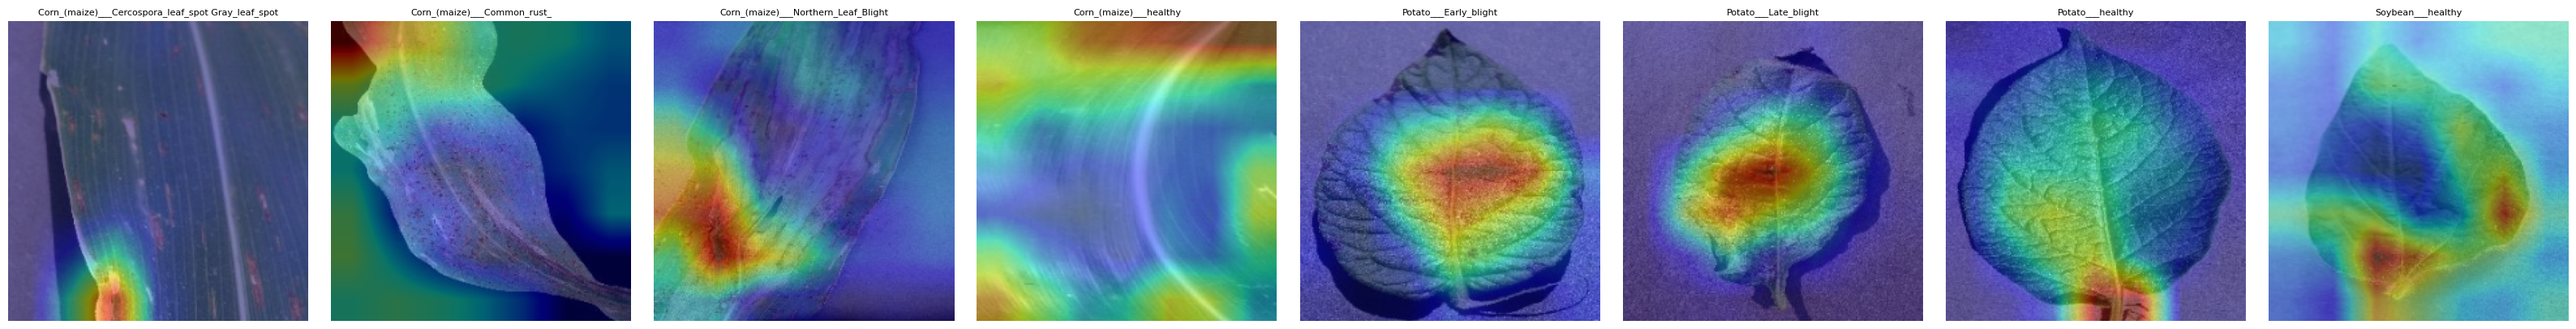

Real Grad-CAM generated for the winning CNN.


In [ ]:
def make_gradcam_heatmap(img_array, cnn_model, base_model, preprocess_fn):
    base_idx = [i for i, l in enumerate(cnn_model.layers) if l is base_model][0]
    head_layers = cnn_model.layers[base_idx + 1:]
    img_processed = preprocess_fn(tf.cast(img_array, tf.float32))
    with tf.GradientTape() as tape:
        conv_outputs = base_model(img_processed, training=False)
        tape.watch(conv_outputs)
        x = conv_outputs
        for layer in head_layers:
            x = layer(x)
        predictions = x
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

if best_model_name == "mobilenetv2":
    cnn_model, cnn_base, preprocess_fn = mobilenet_model, mobilenet_base, mnv2_preprocess
elif best_model_name == "efficientnetb0":
    cnn_model, cnn_base, preprocess_fn = efficientnet_model, efficientnet_base, effnet_preprocess
else:
    cnn_model = None

if cnn_model is not None:
    fig, axes = plt.subplots(1, len(classes), figsize=(4 * len(classes), 4))
    for ci, cls in enumerate(classes):
        fp = sample_paths_by_class[cls]
        img = cv2.cvtColor(cv2.resize(cv2.imread(fp), (IMG_SIZE_CNN, IMG_SIZE_CNN)), cv2.COLOR_BGR2RGB)
        img_array = np.expand_dims(img.astype(np.float32), axis=0)
        heatmap = cv2.resize(make_gradcam_heatmap(img_array, cnn_model, cnn_base, preprocess_fn),
                              (IMG_SIZE_CNN, IMG_SIZE_CNN))
        axes[ci].imshow(img); axes[ci].imshow(heatmap, cmap="jet", alpha=0.45)
        axes[ci].set_title(cls, fontsize=8); axes[ci].axis("off")
    plt.tight_layout(); plt.savefig(f"{OUT_FIG}/disease_gradcam.png", dpi=150); plt.show()
    print("Real Grad-CAM generated for the winning CNN.")
else:
    print("A tree model won -- SHAP + occlusion saliency above are the explainability output.")


## Step 14 — Severity scoring + final save

Uses `predict_proba` / softmax output from the winning model, **never** the ground-truth label.
Uses `TEST_FILE_PATHS` captured back in Step 7, since `.prefetch()` strips `.file_paths` from
the dataset.

**On severity:** `severity_vec` is a hand-authored constant per class (healthy 0.0, early
blight 0.3, late blight 0.6, …). It is not derived from the image and adds nothing to the class
label. `predicted_severity` is the probability-weighted average of those constants. Sourced
yield-loss figures from the extension literature would make this meaningful; the current values
are placeholders.

In [ ]:
import pandas as pd
import json
import joblib

# NOTE: these severity values are hand-authored constants, one per class. They
# are not measured from the images and carry no information beyond the class
# label itself. Replacing them with sourced yield-loss figures from the
# extension literature (e.g. the Crop Protection Network loss database) is the
# intended next step -- see the README.
SEVERITY_MAP_DEFAULTS = {
    "healthy": 0.0, "early_blight": 0.3, "late_blight": 0.6,
    "common_rust": 0.35, "northern_leaf_blight": 0.5,
    "gray_leaf_spot": 0.45, "cercospora_leaf_spot_gray_leaf_spot": 0.45,
}

def build_severity_vector(classes):
    vec = np.full(len(classes), 0.5, dtype=np.float32)
    unresolved = []
    for i, cls in enumerate(classes):
        key = cls.lower().split("___")[-1].replace(" ", "_").replace(",", "")
        matched = False
        for k, v in SEVERITY_MAP_DEFAULTS.items():
            if k in key:
                vec[i] = v; matched = True; break
        if not matched:
            unresolved.append(cls)
    if unresolved:
        print(f"WARNING: fell back to default severity 0.5 for: {unresolved}")
    return vec

severity_vec = build_severity_vector(classes)

if best_model_name in ("mobilenetv2", "efficientnetb0"):
    cnn_final = mobilenet_model if best_model_name == "mobilenetv2" else efficientnet_model
    final_paths = TEST_FILE_PATHS
    proba_best, true_idx = [], []
    for xb, yb in test_ds:
        proba_best.append(cnn_final.predict(xb, verbose=0))
        true_idx.extend(yb.numpy().tolist())
    proba_best = np.concatenate(proba_best)
else:
    final_paths = test_paths
    true_idx = yte
    proba_best = xgb_model.predict_proba(Xte) if best_model_name == "xgboost" else rf.predict_proba(Xte)

pred_severity_best = proba_best @ severity_vec
pred_class_idx_best = np.argmax(proba_best, axis=1)

pred_df = pd.DataFrame({
    "image_path": final_paths,
    "true_class": [classes[i] for i in true_idx],
    "predicted_class": [classes[i] for i in pred_class_idx_best],
    "predicted_severity": pred_severity_best,
})
pred_df.to_csv(f"{OUT_MET}/disease_test_predictions.csv", index=False)

joblib.dump(xgb_model, f"{ART}/disease_model.joblib")
joblib.dump({"classes": classes, "feature_names": FEATURE_NAMES,
             "severity_vec": severity_vec.tolist(), "img_size": IMG_SIZE,
             "best_model": best_model_name}, f"{ART}/disease_meta.joblib")

with open(f"{OUT_MET}/disease_model_metrics.json", "w") as f:
    json.dump({**metrics, "best_model": best_model_name, "split": "test"}, f, indent=2)

print(f"DONE. Best model: {best_model_name}")
print(pred_df.head())

DONE. Best model: efficientnetb0
                                          image_path  \
0  data/images/test/Corn_(maize)___Cercospora_lea...   
1  data/images/test/Corn_(maize)___Cercospora_lea...   
2  data/images/test/Corn_(maize)___Cercospora_lea...   
3  data/images/test/Corn_(maize)___Cercospora_lea...   
4  data/images/test/Corn_(maize)___Cercospora_lea...   

                                          true_class  \
0  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...   
1  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...   
2  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...   
3  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...   
4  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...   

                                     predicted_class  predicted_severity  
0                Corn_(maize)___Northern_Leaf_Blight            0.458220  
1  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...            0.450171  
2  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...            0.45

In [ ]:
# Save the actual winning model,
if best_model_name == "mobilenetv2":
    mobilenet_model.save(f"{ART}/best_disease_model.keras")
    print("Saved MobileNetV2 as best_disease_model.keras")
elif best_model_name == "efficientnetb0":
    efficientnet_model.save(f"{ART}/best_disease_model.keras")
    print("Saved EfficientNetB0 as best_disease_model.keras")
else:
    # if a tree model won, save that instead under the same standardized name
    winning_tree_model = xgb_model if best_model_name == "xgboost" else rf
    joblib.dump(winning_tree_model, f"{ART}/best_disease_model.joblib")
    print(f"Tree model won ({best_model_name}) — saved as best_disease_model.joblib instead")

Saved EfficientNetB0 as best_disease_model.keras


In [ ]:
!zip -rq disease_detection_part.zip artifacts_disease outputs -x "*.DS_Store"
from google.colab import files
files.download("disease_detection_part.zip")
print("Zip ready for download: disease_detection_part.zip")

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    import os
    os.makedirs('/content/drive/MyDrive/agrivision', exist_ok=True)
    !cp disease_detection_part.zip /content/drive/MyDrive/agrivision/
    print("Also backed up to Google Drive.")
except Exception as e:
    print("Drive backup skipped (not required) -- reason:", e)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Zip ready for download: disease_detection_part.zip
Mounted at /content/drive
Also backed up to Google Drive.


#  Crop Disease Detection using Deep Learning

## Project Overview

This notebook develops an AI-based crop disease detection system that identifies diseases from
crop leaf images. Given a leaf photograph, the model predicts the disease class (or healthy
condition) and generates an explainable visual heatmap showing the regions responsible for the
prediction.

It also attaches a **severity value** between 0 (healthy) and 1 (very severe). This value is
looked up from a fixed per-class table defined in Step 14 — it is *not* measured from the image
and carries no information beyond the predicted class. Turning it into a defensible number
requires sourced yield-loss figures from the agronomy literature; see the README.

## Why Multiple Models?

Rather than selecting a single model beforehand, this notebook trains and compares four
different models:

- XGBoost
- Random Forest
- MobileNetV2
- EfficientNetB0

XGBoost and Random Forest serve as machine learning baselines, while MobileNetV2 and
EfficientNetB0 are transfer learning models for image classification. The model with the best
**test** macro-F1 is automatically selected.

## Explainable AI

To improve transparency and trust, Grad-CAM visualizations are generated for deep learning
models. These heatmaps highlight the regions of the leaf that contributed most to the
prediction, helping verify that the model focuses on actual disease symptoms.

## Outputs

The notebook produces:

- Best-performing trained model
- Accuracy, Precision, Recall, and F1-score on a held-out test split
- Confusion Matrix for the winning model
- Grad-CAM visualizations
- Per-image severity lookup values for each test image

---

# Dataset

This project uses the **PlantVillage** dataset, a widely used public benchmark dataset for plant
disease classification.

Only three crops are included:

- Potato
- Corn (Maize)
- Soybean

The dataset contains **8 disease/healthy classes**, capped at 1000 images per class and split
70 / 15 / 15 into train / val / test.

The cap does not make the classes equal: PlantVillage holds only 152 `Potato___healthy`
images in total, so that class stays at 152 while the others reach 1000 -- roughly a 6.6:1
imbalance. All four models are therefore trained with **balanced class weights** so the rare
class is not neglected.

Note that of the three crops, only Corn and Potato have disease classes. Soybean appears solely
as `Soybean___healthy`, so the model can never report a soybean disease.

Both val and test consist of images never used during training. Only **test** is used for the
reported metrics.